In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns

In [2]:
df1 = pd.read_csv('D:/Git_hub/p1/V3/Dataset_Kaggle/dataset1.csv')
print(df1.shape)
df2 = pd.read_csv('D:/Git_hub/p1/V3/Dataset_Kaggle/dataset2.csv')
print(df2.shape)
df3 = pd.read_csv('D:/Git_hub/p1/V3/Dataset_Kaggle/dataset3.csv')
print(df3.shape)

(8234, 2)
(1000, 5)
(1000, 11)


In [3]:
df1.head(5)

,Resume,Category
0,Python Developer Python Developer Philadelphia...,Python_Developer
1,Python Developer Python Developer Python Devel...,Python_Developer
2,R&D Engineer R&D Engineer R&D Engineer - Nokia...,Python_Developer
3,Sr. Full Stack Developer Sr. Full Stack Develo...,Python_Developer
4,Sr. Full Stack Python Developer Sr. Full Stack...,Python_Developer


In [4]:
df1 = df1.rename(columns={
    "Resume": "text",
    "Category": "role"
})

In [5]:
df1.columns

Index(['text', 'role'], dtype='object')

In [6]:
df1.isnull().sum()

text    0
role    0
dtype: int64

In [7]:
df1.duplicated().sum()

np.int64(67)

DATA DUPLICAY REMOVING

In [8]:
df1 = df1.drop_duplicates()

In [9]:
df1.duplicated().sum()

np.int64(0)

Inspect Raw Resume Text

Before cleaning text, we must see how the resumes actually look.

In [10]:
df1['text'].iloc[0]

"Python Developer Python Developer Philadelphia, PA Work Experience Python Developer December 2017 to Present Python Developer 2 Years Education Bachelor's in Computer Science Philadelphia, PA"

In [11]:
df1['text'] = df1['text'].str.lower()

In [12]:
df1['text'].iloc[0]

"python developer python developer philadelphia, pa work experience python developer december 2017 to present python developer 2 years education bachelor's in computer science philadelphia, pa"

In [13]:
import re

df1['text'] = df1['text'].apply(lambda x: re.sub(r'[^a-z\s]', ' ', x))

In [14]:
df1['text'].iloc[0]

'python developer python developer philadelphia  pa work experience python developer december      to present python developer   years education bachelor s in computer science philadelphia  pa'

In [15]:
df1['text'] = df1['text'].str.replace(r'\s+', ' ', regex=True)

In [16]:
df1['text'] = df1['text'].str.strip()

In [17]:
df1['text'].iloc[0]

'python developer python developer philadelphia pa work experience python developer december to present python developer years education bachelor s in computer science philadelphia pa'

In [18]:
df1['role'] = df1['role'].str.replace('_', ' ')

In [19]:
df1['role'] = df1['role'].str.lower()

In [20]:
df1['role'].unique()

array(['python developer', 'java developer', 'front end developer',
       'network administrator', 'project manager', 'security analyst',
       'software developer', 'systems administrator', 'web developer',
       'database administrator'], dtype=object)

In [21]:
df1 = df1.copy()

In [22]:
df1['role'].value_counts()

role
python developer          1278
java developer            1206
web developer              968
database administrator     920
security analyst           875
systems administrator      769
project manager            722
front end developer        523
network administrator      469
software developer         437
Name: count, dtype: int64

In [23]:
df1.head()

,text,role
0,python developer python developer philadelphia...,python developer
1,python developer python developer python devel...,python developer
2,r d engineer r d engineer r d engineer nokia s...,python developer
3,sr full stack developer sr full stack develope...,python developer
4,sr full stack python developer sr full stack p...,python developer


In [24]:
df2.head()

,candidate_id,skills,qualification,experience_level,job_role
0,1,"Python, SQL, TensorFlow, Machine Learning, Com...",Master's in Data Science,Senior,Data Scientist
1,2,"HTML, CSS, JavaScript, React, Teamwork",Bachelor's in Computer Science,Mid,Frontend Developer
2,3,"Java, Spring, SQL, REST APIs, Problem Solving",Bachelor's in Software Engineering,Senior,Backend Developer
3,4,"Figma, Adobe XD, UI/UX Design, Creativity",Bachelor's in Design,Entry,Designer
4,5,"Python, Django, JavaScript, React, Agile",Master's in Computer Science,Mid,Full Stack Python Developer


In [25]:
df2 = df2[['skills', 'qualification', 'experience_level', 'job_role']]

In [26]:
df2.head()

,skills,qualification,experience_level,job_role
0,"Python, SQL, TensorFlow, Machine Learning, Com...",Master's in Data Science,Senior,Data Scientist
1,"HTML, CSS, JavaScript, React, Teamwork",Bachelor's in Computer Science,Mid,Frontend Developer
2,"Java, Spring, SQL, REST APIs, Problem Solving",Bachelor's in Software Engineering,Senior,Backend Developer
3,"Figma, Adobe XD, UI/UX Design, Creativity",Bachelor's in Design,Entry,Designer
4,"Python, Django, JavaScript, React, Agile",Master's in Computer Science,Mid,Full Stack Python Developer


In [27]:
df2['text'] = df2['skills'] + ' ' + df2['qualification'] + ' ' + df2['experience_level']

In [28]:
df2 = df2.rename(columns={'job_role': 'role'})

In [29]:
df2 = df2[['text', 'role']]

In [30]:
df2.head()

,text,role
0,"Python, SQL, TensorFlow, Machine Learning, Com...",Data Scientist
1,"HTML, CSS, JavaScript, React, Teamwork Bachelo...",Frontend Developer
2,"Java, Spring, SQL, REST APIs, Problem Solving ...",Backend Developer
3,"Figma, Adobe XD, UI/UX Design, Creativity Bach...",Designer
4,"Python, Django, JavaScript, React, Agile Maste...",Full Stack Python Developer


In [31]:
import re

df2['text'] = (
    df2['text']
    .str.lower()
    .apply(lambda x: re.sub(r'[^a-z\s]', ' ', x))
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)

In [32]:
df2['text'].iloc[0]

'python sql tensorflow machine learning communication master s in data science senior'

In [33]:
df2['role'] = df2['role'].str.lower()

In [34]:
df2['role'].unique()

array(['data scientist', 'frontend developer', 'backend developer',
       'designer', 'full stack python developer', 'finance',
       'game developer', 'devops engineer', 'full stack java developer',
       'blockchain developer', 'marketing', 'hr', 'c# developer',
       'php developer', 'mobile developer', 'cybersecurity engineer',
       'software project manager', 'video game designer', 'data analyst',
       'kubernetes operations engineer', 'web developer', 'aiml'],
      dtype=object)

In [35]:
df2.isnull().sum()

text    0
role    0
dtype: int64

In [36]:
df2.duplicated().sum()

np.int64(900)

In [37]:
df2 = df2.drop_duplicates()

In [38]:
df2.duplicated().sum()

np.int64(0)

In [39]:
df2.isnull().sum()

text    0
role    0
dtype: int64

In [40]:
df3.head()

,Resume_ID,Name,Skills,Experience (Years),Education,Certifications,Job Role,Recruiter Decision,Salary Expectation ($),Projects Count,AI Score (0-100)
0,1,Ashley Ali,"TensorFlow, NLP, Pytorch",10,B.Sc,NaN,AI Researcher,Hire,104895,8,100
1,2,Wesley Roman,"Deep Learning, Machine Learning, Python, SQL",10,MBA,Google ML,Data Scientist,Hire,113002,1,100
2,3,Corey Sanchez,"Ethical Hacking, Cybersecurity, Linux",1,MBA,Deep Learning Specialization,Cybersecurity Analyst,Hire,71766,7,70
3,4,Elizabeth Carney,"Python, Pytorch, TensorFlow",7,B.Tech,AWS Certified,AI Researcher,Hire,46848,0,95
4,5,Julie Hill,"SQL, React, Java",4,PhD,NaN,Software Engineer,Hire,87441,9,100


In [41]:
df3.columns

Index(['Resume_ID', 'Name', 'Skills', 'Experience (Years)', 'Education',
       'Certifications', 'Job Role', 'Recruiter Decision',
       'Salary Expectation ($)', 'Projects Count', 'AI Score (0-100)'],
      dtype='object')

In [42]:
df3 = df3[['Skills', 'Experience (Years)', 'Education', 'Certifications', 'Job Role']]

In [43]:
df3.columns

Index(['Skills', 'Experience (Years)', 'Education', 'Certifications',
       'Job Role'],
      dtype='object')

In [44]:
df3.head()

,Skills,Experience (Years),Education,Certifications,Job Role
0,"TensorFlow, NLP, Pytorch",10,B.Sc,NaN,AI Researcher
1,"Deep Learning, Machine Learning, Python, SQL",10,MBA,Google ML,Data Scientist
2,"Ethical Hacking, Cybersecurity, Linux",1,MBA,Deep Learning Specialization,Cybersecurity Analyst
3,"Python, Pytorch, TensorFlow",7,B.Tech,AWS Certified,AI Researcher
4,"SQL, React, Java",4,PhD,NaN,Software Engineer


In [45]:
df3['text'] = (
    df3['Skills'].astype(str) + ' ' +
    df3['Experience (Years)'].astype(str) + ' years ' +
    df3['Education'].astype(str) + ' ' +
    df3['Certifications'].astype(str)
)

In [46]:
df3 = df3.rename(columns={'Job Role': 'role'})

In [47]:
df3 = df3[['text', 'role']]

In [48]:
df3.head()

,text,role
0,"TensorFlow, NLP, Pytorch 10 years B.Sc nan",AI Researcher
1,"Deep Learning, Machine Learning, Python, SQL 1...",Data Scientist
2,"Ethical Hacking, Cybersecurity, Linux 1 years ...",Cybersecurity Analyst
3,"Python, Pytorch, TensorFlow 7 years B.Tech AWS...",AI Researcher
4,"SQL, React, Java 4 years PhD nan",Software Engineer


In [49]:
import re

df3['text'] = (
    df3['text']
    .str.lower()
    .apply(lambda x: re.sub(r'[^a-z\s]', ' ', x))
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)

In [50]:
df3['role'] = df3['role'].str.lower()

In [51]:
df3.isnull().sum()

text    0
role    0
dtype: int64

In [52]:
df3.duplicated().sum()

np.int64(88)

In [53]:
df3 = df3.drop_duplicates()

In [54]:
df3.duplicated().sum()

np.int64(0)

###### Dataset Merging

In [55]:
final_df = pd.concat([df1, df2, df3], ignore_index=True)


In [56]:
final_df.shape

(9179, 2)

In [57]:
final_df.columns

Index(['text', 'role'], dtype='object')

In [58]:
final_df.duplicated

<bound method DataFrame.duplicated of                                                    text                   role
0     python developer python developer philadelphia...       python developer
1     python developer python developer python devel...       python developer
2     r d engineer r d engineer r d engineer nokia s...       python developer
3     sr full stack developer sr full stack develope...       python developer
4     sr full stack python developer sr full stack p...       python developer
...                                                 ...                    ...
9174                     react java years phd google ml      software engineer
9175  cybersecurity linux ethical hacking years b sc...  cybersecurity analyst
9176  deep learning machine learning years mba deep ...         data scientist
9177  linux networking cybersecurity ethical hacking...  cybersecurity analyst
9178  sql machine learning python deep learning year...         data scientist

[9179 rows x 

In [59]:
final_df.duplicated().sum()

np.int64(173)

In [60]:
final_df = final_df.drop_duplicates()

In [61]:
final_df.duplicated().sum()
final_df.shape

(9006, 2)

##### ML Preprocessing

In [62]:
final_df['role'].value_counts()

role
python developer                  1271
java developer                    1182
web developer                      927
database administrator             920
security analyst                   874
systems administrator              768
project manager                    722
network administrator              468
software developer                 437
front end developer                429
ai researcher                      236
cybersecurity analyst              232
data scientist                     231
software engineer                  218
mobile developer                     7
game developer                       6
marketing                            6
data analyst                         6
software project manager             6
cybersecurity engineer               5
frontend developer                   5
backend developer                    5
kubernetes operations engineer       5
full stack python developer          5
hr                                   5
blockchain developer

In [63]:
X = final_df['text']
y = final_df['role']

In [64]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X_tfidf = tfidf.fit_transform(X)

In [65]:
X_tfidf.shape

(9006, 5000)

In [66]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42
)

In [67]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(7204, 5000)
(1802, 5000)
(7204,)
(1802,)


In [68]:
y_train.value_counts()

role
python developer                  1016
java developer                     948
database administrator             753
web developer                      735
security analyst                   708
systems administrator              619
project manager                    578
network administrator              359
front end developer                349
software developer                 345
ai researcher                      196
cybersecurity analyst              193
data scientist                     171
software engineer                  169
mobile developer                     6
data analyst                         5
cybersecurity engineer               5
game developer                       5
software project manager             4
designer                             4
devops engineer                      4
kubernetes operations engineer       4
full stack python developer          4
full stack java developer            4
blockchain developer                 4
hr                  

In [69]:
# Get valid roles
role_counts = y_train.value_counts()
valid_roles = role_counts[role_counts >= 5].index

# Create mask
mask = y_train.isin(valid_roles)

# Apply filtering correctly
X_train = X_train[mask.values]
y_train = y_train[mask]

In [70]:
y_train.value_counts()

role
python developer          1016
java developer             948
database administrator     753
web developer              735
security analyst           708
systems administrator      619
project manager            578
network administrator      359
front end developer        349
software developer         345
ai researcher              196
cybersecurity analyst      193
data scientist             171
software engineer          169
mobile developer             6
game developer               5
data analyst                 5
cybersecurity engineer       5
Name: count, dtype: int64

In [71]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(k_neighbors = 3 ,random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

In [72]:
y_train_res.value_counts()

role
systems administrator     1016
software developer        1016
data analyst              1016
game developer            1016
mobile developer          1016
cybersecurity analyst     1016
network administrator     1016
front end developer       1016
data scientist            1016
software engineer         1016
ai researcher             1016
python developer          1016
java developer            1016
security analyst          1016
web developer             1016
project manager           1016
database administrator    1016
cybersecurity engineer    1016
Name: count, dtype: int64

In [73]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train_res, y_train_res)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [74]:
y_pred = model.predict(X_test)

In [75]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8862375138734739
                                precision    recall  f1-score   support

                 ai researcher       0.98      1.00      0.99        40
                          aiml       0.00      0.00      0.00         1
             backend developer       0.00      0.00      0.00         3
          blockchain developer       0.00      0.00      0.00         1
                  c# developer       0.00      0.00      0.00         1
         cybersecurity analyst       1.00      1.00      1.00        39
        cybersecurity engineer       0.00      0.00      0.00         0
                  data analyst       1.00      1.00      1.00         1
                data scientist       1.00      1.00      1.00        60
        database administrator       0.93      0.93      0.93       167
                      designer       0.00      0.00      0.00         1
           front end developer       0.64      0.65      0.65        80
            frontend developer    

d:\Anaconda_jupyter\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Anaconda_jupyter\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Anaconda_jupyter\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Anaconda_jupyter\Lib\site-packages\sklearn\metri

In [76]:
print(final_df['role'].unique())

['python developer' 'java developer' 'front end developer'
 'network administrator' 'project manager' 'security analyst'
 'software developer' 'systems administrator' 'web developer'
 'database administrator' 'data scientist' 'frontend developer'
 'backend developer' 'designer' 'full stack python developer' 'finance'
 'game developer' 'devops engineer' 'full stack java developer'
 'blockchain developer' 'marketing' 'hr' 'c# developer' 'php developer'
 'mobile developer' 'cybersecurity engineer' 'software project manager'
 'video game designer' 'data analyst' 'kubernetes operations engineer'
 'aiml' 'ai researcher' 'cybersecurity analyst' 'software engineer']


In [77]:
role_mapping = {
    "front end developer": "frontend developer",
    "frontend developer": "frontend developer",
    
    "software developer": "software engineer",
    "software engineer": "software engineer",
    
    "project manager": "project manager",
    "software project manager": "project manager"
}

In [78]:
final_df['role'] = final_df['role'].map(role_mapping).fillna(final_df['role'])

C:\Users\singl\AppData\Local\Temp\ipykernel_7304\3182558829.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_df['role'] = final_df['role'].map(role_mapping).fillna(final_df['role'])


In [79]:
print(final_df['role'].unique())

['python developer' 'java developer' 'frontend developer'
 'network administrator' 'project manager' 'security analyst'
 'software engineer' 'systems administrator' 'web developer'
 'database administrator' 'data scientist' 'backend developer' 'designer'
 'full stack python developer' 'finance' 'game developer'
 'devops engineer' 'full stack java developer' 'blockchain developer'
 'marketing' 'hr' 'c# developer' 'php developer' 'mobile developer'
 'cybersecurity engineer' 'video game designer' 'data analyst'
 'kubernetes operations engineer' 'aiml' 'ai researcher'
 'cybersecurity analyst']


In [80]:
role_mapping.update({
    "video game designer": "game developer",
    "security analyst": "cybersecurity analyst"
})

In [81]:
final_df['role'] = final_df['role'].map(role_mapping).fillna(final_df['role'])

C:\Users\singl\AppData\Local\Temp\ipykernel_7304\3182558829.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_df['role'] = final_df['role'].map(role_mapping).fillna(final_df['role'])


In [82]:
print(final_df['role'].unique())

['python developer' 'java developer' 'frontend developer'
 'network administrator' 'project manager' 'cybersecurity analyst'
 'software engineer' 'systems administrator' 'web developer'
 'database administrator' 'data scientist' 'backend developer' 'designer'
 'full stack python developer' 'finance' 'game developer'
 'devops engineer' 'full stack java developer' 'blockchain developer'
 'marketing' 'hr' 'c# developer' 'php developer' 'mobile developer'
 'cybersecurity engineer' 'data analyst' 'kubernetes operations engineer'
 'aiml' 'ai researcher']


In [83]:
remove_roles = ['hr', 'marketing', 'finance']

final_df = final_df[~final_df['role'].isin(remove_roles)]

In [84]:
print(final_df['role'].value_counts())

role
python developer                  1271
java developer                    1182
cybersecurity analyst             1106
web developer                      927
database administrator             920
systems administrator              768
project manager                    728
software engineer                  655
network administrator              468
frontend developer                 434
ai researcher                      236
data scientist                     231
game developer                       7
mobile developer                     7
data analyst                         6
backend developer                    5
designer                             5
full stack java developer            5
blockchain developer                 5
cybersecurity engineer               5
kubernetes operations engineer       5
full stack python developer          5
devops engineer                      4
c# developer                         3
php developer                        3
aiml                

In [85]:
final_df['role'].value_counts()

role
python developer                  1271
java developer                    1182
cybersecurity analyst             1106
web developer                      927
database administrator             920
systems administrator              768
project manager                    728
software engineer                  655
network administrator              468
frontend developer                 434
ai researcher                      236
data scientist                     231
game developer                       7
mobile developer                     7
data analyst                         6
backend developer                    5
designer                             5
full stack java developer            5
blockchain developer                 5
cybersecurity engineer               5
kubernetes operations engineer       5
full stack python developer          5
devops engineer                      4
c# developer                         3
php developer                        3
aiml                

In [86]:
role_counts = final_df['role'].value_counts()

valid_roles = role_counts[role_counts >= 10].index

final_df = final_df[final_df['role'].isin(valid_roles)]

In [87]:
final_df['role'].value_counts()

role
python developer          1271
java developer            1182
cybersecurity analyst     1106
web developer              927
database administrator     920
systems administrator      768
project manager            728
software engineer          655
network administrator      468
frontend developer         434
ai researcher              236
data scientist             231
Name: count, dtype: int64

In [88]:
X = final_df['text']
y = final_df['role']

#  TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf.fit_transform(X)

#  Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42
)

In [89]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [90]:
y_pred = model.predict(X_test)

In [91]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9020156774916014
                        precision    recall  f1-score   support

         ai researcher       1.00      1.00      1.00        56
 cybersecurity analyst       0.97      0.98      0.98       225
        data scientist       1.00      1.00      1.00        48
database administrator       0.96      0.95      0.95       183
    frontend developer       0.64      0.61      0.62        79
        java developer       0.99      0.98      0.98       232
 network administrator       0.84      0.68      0.75        96
       project manager       0.91      0.96      0.93       134
      python developer       0.99      1.00      0.99       262
     software engineer       0.89      0.64      0.74       144
 systems administrator       0.76      0.87      0.81       130
         web developer       0.75      0.91      0.82       197

              accuracy                           0.90      1786
             macro avg       0.89      0.88      0.88      1786
         

NameError: name 'plt' is not defined

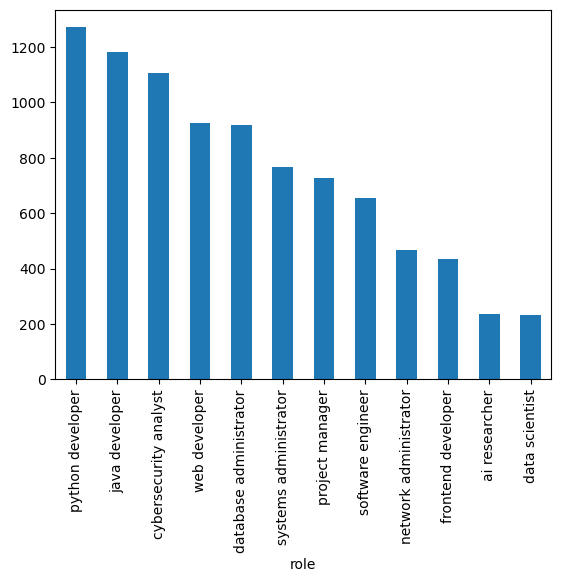

In [92]:
final_df['role'].value_counts().plot(kind='bar')

plt.title("Role Distribution")
plt.xlabel("Roles")
plt.ylabel("Count")
plt.xticks(rotation=90)

plt.show()

In [ ]:
role_group_mapping = {
    "python developer": "software developer",
    "java developer": "software developer",
    "software engineer": "software developer",

    "frontend developer": "web developer",
    "web developer": "web developer",

    "systems administrator": "system admin",
    "network administrator": "system admin",

    "database administrator": "database",

    "cybersecurity analyst": "cybersecurity",

    "ai researcher": "data/ai",
    "data scientist": "data/ai",

    "project manager": "management"
}

In [ ]:
final_df['role'] = final_df['role'].map(role_group_mapping)

In [ ]:
print(final_df['role'].unique())

['software developer' 'web developer' 'system admin' 'management'
 'cybersecurity' 'database' 'data/ai']


In [ ]:
# Feature & Label
X = final_df['text']
y = final_df['role']

# TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf.fit_transform(X)

# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.93505039193729
                    precision    recall  f1-score   support

     cybersecurity       0.99      0.97      0.98       225
           data/ai       0.99      1.00      1.00       104
          database       0.96      0.92      0.94       183
        management       0.93      0.93      0.93       134
software developer       0.96      0.91      0.94       638
      system admin       0.92      0.97      0.95       226
     web developer       0.82      0.92      0.87       276

          accuracy                           0.94      1786
         macro avg       0.94      0.95      0.94      1786
      weighted avg       0.94      0.94      0.94      1786



In [ ]:
import pickle

# Save model
with open('model.pkl', 'wb') as f:
    pickle.dump(model, f)

# Save TF-IDF
with open('tfidf.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

In [ ]:
def predict_role(resume_text):
    resume_text = resume_text.lower()
    
    import re
    resume_text = re.sub(r'[^a-z\s]', ' ', resume_text)
    resume_text = re.sub(r'\s+', ' ', resume_text).strip()
    
    vector = tfidf.transform([resume_text])
    prediction = model.predict(vector)
    
    return prediction[0]

In [ ]:
pip install PyPDF2

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import PyPDF2

def extract_text_from_pdf(file_path):
    text = ""
    
    with open(file_path, 'rb') as file:
        reader = PyPDF2.PdfReader(file)
        
        for page in reader.pages:
            extracted = page.extract_text()
            if extracted:   # avoid None
                text += extracted
                
    return text